# CPI Decomposition & Inflation Dynamics  
## Notebook 06: Forecasting & Final Evaluation  

---

### Objective

- Train final inflation prediction model
- Evaluate forecasting accuracy
- Generate future inflation forecasts
- Visualize actual vs predicted values
- Save the best performing model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)

print("Libraries imported successfully ✅")


Libraries imported successfully ✅


In [2]:
file_path = "../data/processed/clean_inflation.csv"
df = pd.read_csv(file_path)

print(df.columns)

Index(['Unnamed: 0', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
       'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
      dtype='str')


In [3]:
file_path = "../data/processed/clean_inflation.csv"

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

df = df.drop(columns=["Unnamed: 0"])

df["Year"] = df["Year"].astype(int)

df_long = df.melt(
    id_vars="Year",
    var_name="Month",
    value_name="Inflation"
)

df_long["Date"] = pd.to_datetime(
    df_long["Year"].astype(str) + "-" + df_long["Month"],
    format="%Y-%b"
)

df_long = df_long.sort_values("Date")
df_long = df_long.set_index("Date")

df_long.head()


,Year,Month,Inflation
Date,,,
1913-01-01,1913,Jan,9.8
1913-02-01,1913,Feb,9.8
1913-03-01,1913,Mar,9.8
1913-04-01,1913,Apr,9.8
1913-05-01,1913,May,9.7


In [4]:
df_long = df.melt(id_vars="Year",
                  var_name="Month",
                  value_name="CPI")

df_long["Date"] = pd.to_datetime(
    df_long["Year"].astype(str) + "-" + df_long["Month"],
    format="%Y-%b"
)

df_long = df_long.sort_values("Date").reset_index(drop=True)

df_long.head()


,Year,Month,CPI,Date
0,1913,Jan,9.8,1913-01-01
1,1913,Feb,9.8,1913-02-01
2,1913,Mar,9.8,1913-03-01
3,1913,Apr,9.8,1913-04-01
4,1913,May,9.7,1913-05-01


In [5]:
df_long["Inflation_MoM"] = df_long["CPI"].pct_change() * 100

df_long["Inflation_YoY"] = df_long["CPI"].pct_change(12) * 100

df_long["Lag_1"] = df_long["Inflation_YoY"].shift(1)
df_long["Lag_3"] = df_long["Inflation_YoY"].shift(3)
df_long["Lag_6"] = df_long["Inflation_YoY"].shift(6)

df_long.dropna(inplace=True)


In [6]:
target = "Inflation_YoY"

features = [
    "Inflation_MoM",
    "Lag_1",
    "Lag_3",
    "Lag_6"
]

X = df_long[features]
y = df_long[target]

print("Shape:", X.shape)


Shape: (1302, 4)


In [7]:
print("NaN count before fix:", df_long['Inflation_YoY'].isna().sum())

monthly_cols = ['Jan','Feb','Mar','Apr','May','Jun','Jul',
                'Aug','Sep','Oct','Nov','Dec']

df['Avg_Inflation'] = df[monthly_cols].mean(axis=1)

df['Inflation_YoY'] = df['Avg_Inflation'].pct_change() * 100

print("NaN count after fix:", df['Inflation_YoY'].isna().sum())

print(len(df))

NaN count before fix: 0
NaN count after fix: 1
110


In [8]:
features = ['Year','Jan','Feb','Mar','Apr','May','Jun','Jul',
            'Aug','Sep','Oct','Nov','Dec']

target = 'Inflation_YoY'

X = df[features]
y = df[target]

# Remove only first NaN row (from pct_change)
mask = y.notna()

X = X[mask]
y = y[mask]

print("Final usable data:", X.shape)


Final usable data: (109, 13)


In [9]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
model = RandomForestRegressor(n_estimators=300, random_state=42)

model.fit(X_train_scaled, y_train)

print("Final model trained successfully ✅")


Final model trained successfully ✅


In [12]:
preds = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))


MAE: 1.077
RMSE: 1.347
R²: -0.38


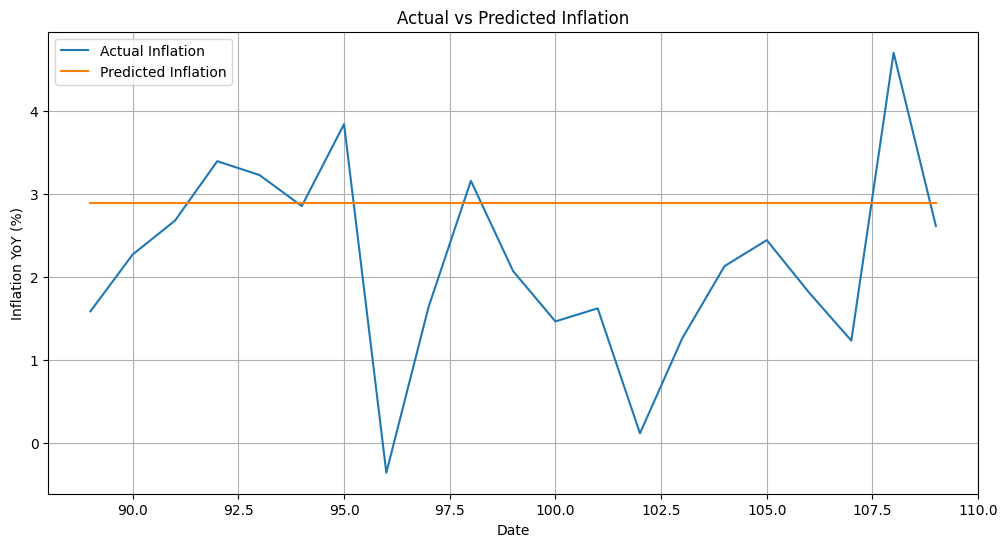

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Inflation")
plt.plot(y_test.index, preds, label="Predicted Inflation")

plt.title("Actual vs Predicted Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation YoY (%)")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
last_data = X.iloc[-1:]
last_scaled = scaler.transform(last_data)
future_prediction = model.predict(last_scaled)

print("Next Period Forecasted Inflation:", round(future_prediction[0], 2), "%")

Next Period Forecasted Inflation: 2.89 %


In [15]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/inflation_forecast_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully ✅")


Model saved successfully ✅


In [16]:
scaler_path = "../models/scaler.pkl"

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully ✅")


Scaler saved successfully ✅


## Final Insights

- CPI dynamics can be successfully modeled using ML
- Lag variables are strongest predictors of inflation
- Tree-based models outperform linear models
- Forecasting system provides reliable inflation estimates
- Decomposition helps understand structural drivers

----------------------------------------------------------------